In [1]:
import os
import re
from pathlib import Path
from enum import Enum
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Metadata about the algorithms

In [2]:
kem_algorithms = ["MLKEM512", "X25519", "bikel1", "p256", "p256_bikel1", "p256_mlkem512",
                  "MLKEM768", "bikel3", "p384", "p384_bikel3", "p384_mlkem768",
                  "MLKEM1024", "p521", "p521_mlkem1024",
                  "hqc128", "hqc192", "hqc256",
                  "kyber90s512", "kyber90s768", "kyber90s1024",
                  "p256_hqc128", "p384_hqc192", "p521_hqc256"]

sig_algorithms = ["falcon512", "rsa:1024", "rsa:2048", "rsa:3072", "rsa:4096", "p256_falcon512",
                  "MLDSA44", "p256_mldsa44", "rsa3072_mldsa44",
                  "MLDSA65", "p384_mldsa65",
                  "MLDSA87",
                  "falcon1024", "p521_falcon1024", "p521_mldsa87",
                  "dilithium2_aes", "dilithium3_aes", "dilithium5_aes",
                  "sphincs128", "sphincs192", "sphincs256",
                  "p256_sphincs128", "p384_sphincs192", "p521_sphincs256"]

standard_algorithms = ["X25519", "p256", "p384", "p521", "rsa:1024", "rsa:2048", "rsa:3072", "rsa:4096"]

security_levels = {"X25519": 1, "MLKEM512": 1, "bikel1": 1, "p256_mlkem512": 1, "p256_bikel1": 1, "p256": 1, "hqc128": 1, "kyber90s512": 1, "p256_hqc128": 1,
                   "falcon512": 1, "p256_falcon512": 1, "rsa:1024": 1, "rsa:2048": 1, "rsa:3072": 1, "rsa:4096": 1, "p256_sphincs128": 1, "sphincs128": 1,

                   "MLDSA44": 2, "p256_mldsa44": 2, "rsa3072_mldsa44": 2, "dilithium2_aes": 2,

                   "MLKEM768": 3, "bikel3": 3, "p384_mlkem768": 3, "p384_bikel3": 3, "p384": 3, "hqc192": 3, "kyber90s768": 3, "p384_hqc192": 3,
                   "MLDSA65": 3, "p384_mldsa65": 3, "dilithium3_aes": 3, "p384_sphincs192": 3, "sphincs192": 3,

                   "MLKEM1024": 5, "p521_mlkem1024": 5, "p521": 5, "hqc256": 5, "kyber90s1024": 5, "p521_hqc256": 5,
                   "MLDSA87": 5, "falcon1024": 5, "p521_mldsa87": 5, "p521_falcon1024": 5, "dilithium5_aes": 5, "p521_sphincs256": 5, "sphincs256": 5}

renaming_new_to_old = {"MLKEM512": "kyber512",
                       "MLKEM768": "kyber768",
                       "MLKEM1024": "kyber1024",
                       "p256_mlkem512": "p256_kyber512",
                       "p384_mlkem768": "p384_kyber768",
                       "p521_mlkem1024": "p521_kyber1024",
                       "MLDSA44": "dilithium2",
                       "MLDSA65": "dilithium3",
                       "MLDSA87": "dilithium5",
                       "p256_mldsa44": "p256_dilithium2",
                       "p384_mldsa65": "p384_dilithium3",
                       "p521_mldsa87": "p521_dilithium5",
                       "rsa3072_mldsa44": "rsa3072_dilithium2"}

renaming_old_to_new = {old: new for new, old in renaming_new_to_old.items()}

scenario_no_emulation = "no emulation"
scenario_rate_1mbit = "rate 1mbit"
scenario_delay_500ms = "delay 500ms"
scenario_loss_10 = "loss 10%"
scenario_loss_4_delay_22_rate_880 = "loss 4% delay 22ms rate 880mbit"
scenario_loss_10_delay_100_rate_1 = "loss 10% delay 100ms rate 1mbit"

all_scenarios = [scenario_no_emulation,
                 scenario_rate_1mbit,
                 scenario_delay_500ms,
                 scenario_loss_10,
                 scenario_loss_4_delay_22_rate_880,
                 scenario_loss_10_delay_100_rate_1]

scenario_aliases = {"low bandwidth": scenario_rate_1mbit, 
                    "high delay": scenario_delay_500ms}

## Data classes

In [3]:
class Measurement:
    def __init__(self):
        self.benchmark_part_a_median = 0.0
        self.benchmark_part_b_median = 0.0
        self.benchmark_part_all_median = 0.0
        self.benchmark_connections = 0
        self.benchmark_clientServerBytes = 0
        self.benchmark_serverClientBytes = 0

        self.reproduced_part_a_median = 0.0
        self.reproduced_part_b_median = 0.0
        self.reproduced_part_all_median = 0.0
        self.reproduced_connections = 0
        self.reproduced_clientServerBytes = 0
        self.reproduced_serverClientBytes = 0

        self.part_a_median_measurements = []
        self.part_b_median_measurements = []
        self.part_all_median_measurements = []
        self.connection_measurements = []
        self.clientServerBytes_measurements = []
        self.serverClientBytes_measurements = []

    #benchmark (original results from the paper)
    def set_benchmark_part_a_median(self, value: float): self.benchmark_part_a_median = value
    def get_benchmark_part_a_median(self): return self.benchmark_part_a_median

    def set_benchmark_part_b_median(self, value: float): self.benchmark_part_b_median = value
    def get_benchmark_part_b_median(self): return self.benchmark_part_b_median

    def set_benchmark_part_all_median(self, value: float): self.benchmark_part_all_median = value
    def get_benchmark_part_all_median(self): return self.benchmark_part_all_median

    def set_benchmark_connections(self, value: int): self.benchmark_connections = value
    def get_benchmark_connections(self): return self.benchmark_connections

    def set_benchmark_clientServerBytes(self, value: int): self.benchmark_clientServerBytes = value
    def get_benchmark_clientServerBytes(self): return self.benchmark_clientServerBytes

    def set_benchmark_serverClientBytes(self, value: int): self.benchmark_serverClientBytes = value
    def get_benchmark_serverClientBytes(self): return self.benchmark_serverClientBytes

    #reproduced (reproduced results with the original code from the authors)
    def set_reproduced_part_a_median(self, value: float): self.reproduced_part_a_median = value
    def get_reproduced_part_a_median(self): return self.reproduced_part_a_median

    def set_reproduced_part_b_median(self, value: float): self.reproduced_part_b_median = value
    def get_reproduced_part_b_median(self): return self.reproduced_part_b_median

    def set_reproduced_part_all_median(self, value: float): self.reproduced_part_all_median = value
    def get_reproduced_part_all_median(self): return self.reproduced_part_all_median

    def set_reproduced_connections(self, value: int): self.reproduced_connections = value
    def get_reproduced_connections(self): return self.reproduced_connections

    def set_reproduced_clientServerBytes(self, value: int): self.reproduced_clientServerBytes = value
    def get_reproduced_clientServerBytes(self): return self.reproduced_clientServerBytes

    def set_reproduced_serverClientBytes(self, value: int): self.reproduced_serverClientBytes = value
    def get_reproduced_serverClientBytes(self): return self.reproduced_serverClientBytes

    #repeated measurements (made with the adapted code)
    def add_part_a_median_measurement(self, measurement: float): self.part_a_median_measurements.append(measurement)
    def get_part_a_median_measurements(self): return self.part_a_median_measurements

    def add_part_b_median_measurement(self, measurement: float): self.part_b_median_measurements.append(measurement)
    def get_part_b_median_measurements(self): return self.part_b_median_measurements

    def add_part_all_median_measurement(self, measurement: float): self.part_all_median_measurements.append(measurement)
    def get_part_all_median_measurements(self): return self.part_all_median_measurements

    def add_connection_measurement(self, measurement: int): self.connection_measurements.append(measurement)
    def get_connection_measurements(self): return self.connection_measurements

    def add_clientServerBytes_measurement(self, measurement: int): self.clientServerBytes_measurements.append(measurement)
    def get_clientServerBytes_measurements(self): return self.clientServerBytes_measurements

    def add_serverClientBytes_measurement(self, measurement: int): self.serverClientBytes_measurements.append(measurement)
    def get_serverClientBytes_measurements(self): return self.serverClientBytes_measurements

#there are three types of algorithms
class AlgorithmType(Enum):
    standard_algorithm = 0
    hybrid_algorithm = 1
    pqs_algorithm = 2

#for the single measurements where one one algorithm is fixed (like in all-kem -> here we use every kem algorithm and fix the sig algorithm to rsa:2048)
class Algorithm:
    def __init__(self, algorithm_type: AlgorithmType, name: str, old_name: str, security_level: int):
        self.algorithm_type = algorithm_type
        self.name = name
        self.old_name = old_name
        self.security_level = security_level
        self.Measurements = {scenario: Measurement() for scenario in all_scenarios}

    def get_algorithm_type(self): return self.algorithm_type
    def get_name(self): return self.name
    def get_old_name(self): return self.old_name
    def get_security_level(self): return self.security_level

    def get_Measurement(self, typ: str):
        t = str(typ).strip().lower()
        t = scenario_aliases.get(t, t)  #workaround to keep old calls like low bandwidth/high delay working
        return self.Measurements[t]

## Some naming normalization and conversion helper functions

In [4]:
#normalizes raw names so escaped underscores and normal underscores match.
def normalize(name: str) -> str:
    return str(name).strip().replace("\\_", "_")

known_names = set(kem_algorithms + sig_algorithms + list(renaming_new_to_old.keys()) + list(renaming_new_to_old.values()))
known_by_normalized = {normalize(n).lower(): n for n in known_names}
old_to_new_normalized = {normalize(old).lower(): normalize(new) for old, new in renaming_old_to_new.items()}

#converts csv algorithm names to internal naming (including old -> new rename mapping)
def normalize_alg_name(name):
    if pd.isna(name):
        return None
    n = normalize(name)
    n_lower = n.lower()
    if n_lower in old_to_new_normalized:
        n = old_to_new_normalized[n_lower]
    return known_by_normalized.get(n.lower(), n)

def display_new_name(name: str) -> str:
    n = normalize_alg_name(name)
    return n if n is not None else str(name)

#call with registry dict and raw csv name; returns existing registry key or None
def resolve_registry_key(registry: dict, raw_name):
    n = normalize_alg_name(raw_name)
    if n is None:
        return None
    if n in registry:
        return n
    normalized_registry = {normalize(k).lower(): k for k in registry.keys()}
    return normalized_registry.get(normalize(n).lower())

#function to turn the number of connections from k into integers (to calculate the delta)
def to_int_k(x) -> int:
    if pd.isna(x):
        return 0
    s = str(x).strip().lower().replace(",", "")
    if s.endswith("k"):
        return int(float(s[:-1]) * 1000)
    return int(float(s))

#filters rows by exact scenario key (supports old aliases low bandwidth/high delay)
def row_matches_emulation(row: pd.Series, measurement_type: str) -> bool:
    traffic_raw = row.get("trafficEmulation", "")
    traffic = "" if pd.isna(traffic_raw) else str(traffic_raw).strip().lower()
    traffic = scenario_no_emulation if traffic == "" else traffic
    wanted = str(measurement_type).strip().lower()
    wanted = scenario_aliases.get(wanted, wanted)
    return traffic == wanted

#writes one csv row into benchmark or reproduced fields of a measurement
def set_scalar_measurement(measurement: Measurement, row: pd.Series, target: str):
    part_a = float(row.get("partAMedian"))
    part_b = float(row.get("partBMedian"))
    part_all = float(row.get("partAllMedian"))
    connections = to_int_k(row.get("connections"))
    client = int(float(row.get("clientServerBytes")))
    server = int(float(row.get("serverClientBytes")))
    if target == "benchmark":
        measurement.set_benchmark_part_a_median(part_a)
        measurement.set_benchmark_part_b_median(part_b)
        measurement.set_benchmark_part_all_median(part_all)
        measurement.set_benchmark_connections(connections)
        measurement.set_benchmark_clientServerBytes(client)
        measurement.set_benchmark_serverClientBytes(server)
    else:
        measurement.set_reproduced_part_a_median(part_a)
        measurement.set_reproduced_part_b_median(part_b)
        measurement.set_reproduced_part_all_median(part_all)
        measurement.set_reproduced_connections(connections)
        measurement.set_reproduced_clientServerBytes(client)
        measurement.set_reproduced_serverClientBytes(server)

## Functions to extract the data from the csvs

In [5]:
#loads algorithm data from a csv into all_kem or all_sig
def extract_scalar_algorithm_data(registry: dict, file_path: Path, algorithm_col: str, measurement_type: str, target: str):
    df = pd.read_csv(file_path)
    for _, row in df.iterrows():
        if not row_matches_emulation(row, measurement_type):
            continue
        key = resolve_registry_key(registry, row.get(algorithm_col))
        if key is None:
            continue
        set_scalar_measurement(registry[key].get_Measurement(measurement_type), row, target)

#loads repeated run algorithm data from many csvs and appends lists in objects
def extract_repeated_algorithm_data(registry: dict, files: list[Path], algorithm_col: str, measurement_type: str):
    for file_path in files:
        df = pd.read_csv(file_path)
        for _, row in df.iterrows():
            if not row_matches_emulation(row, measurement_type):
                continue
            key = resolve_registry_key(registry, row.get(algorithm_col))
            if key is None:
                continue
            m = registry[key].get_Measurement(measurement_type)
            m.add_part_a_median_measurement(float(row.get("partAMedian")))
            m.add_part_b_median_measurement(float(row.get("partBMedian")))
            m.add_part_all_median_measurement(float(row.get("partAllMedian")))
            m.add_connection_measurement(to_int_k(row.get("connections")))
            m.add_clientServerBytes_measurement(int(row.get("clientServerBytes")))
            m.add_serverClientBytes_measurement(int(row.get("serverClientBytes")))

## File sorting and path stuff

In [6]:
#extracts number from a csv filename so files are sorted in true run order
def natural_csv_sort_key(path: Path):
    m = re.search(r"(\d+)(?=\.csv$)", path.name)
    return int(m.group(1)) if m else -1

#finds matching csv files in a folder and sorts them by run index
def sorted_csv_files(
    folder: Path,
    pattern: str,
    min_index: int | None = None,
    max_index: int | None = None
) -> list[Path]:
    files = list(folder.glob(pattern))
    files.sort(key=natural_csv_sort_key)
    if min_index is not None:
        files = [f for f in files if natural_csv_sort_key(f) >= min_index]
    if max_index is not None:
        files = [f for f in files if natural_csv_sort_key(f) <= max_index]
    return files

#finds repo root so paths are machine-independent.
def find_project_root() -> Path:
    env_root = os.getenv("RNS_CHALLENGE_ROOT")
    if env_root:
        p = Path(env_root).expanduser().resolve()
        if not ((p / "tum-evaluate").is_dir() and (p / "results").is_dir()):
            raise FileNotFoundError(p)
        return p
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "tum-evaluate").is_dir() and (p / "results").is_dir():
            return p

## Build objects

In [7]:
#build the algorithm objects
def build_registry(algorithms: list[str]) -> dict:
    reg = {}
    for algorithm in algorithms:
        if algorithm in standard_algorithms:
            algorithm_type = AlgorithmType.standard_algorithm
        elif "_" in algorithm and  "_aes" not in algorithm:
            algorithm_type = AlgorithmType.hybrid_algorithm
        else:
            algorithm_type = AlgorithmType.pqs_algorithm
        old_name = renaming_new_to_old.get(algorithm)
        reg[algorithm] = Algorithm( algorithm_type = algorithm_type, name = algorithm, old_name = old_name, security_level = security_levels[algorithm])
    return reg

## Boxplot function

In [ ]:
def boxplots(dictionary, emulation, measurement, title = None, ylabel = None):
    getters = {"part a median": (Measurement.get_part_a_median_measurements, Measurement.get_reproduced_part_a_median, Measurement.get_benchmark_part_a_median),
               "part b median": (Measurement.get_part_b_median_measurements, Measurement.get_reproduced_part_b_median, Measurement.get_benchmark_part_b_median),
               "part all median": (Measurement.get_part_all_median_measurements, Measurement.get_reproduced_part_all_median, Measurement.get_benchmark_part_all_median),
               "connections": (Measurement.get_connection_measurements, Measurement.get_reproduced_connections, Measurement.get_benchmark_connections),
               "clientServerBytes": (Measurement.get_clientServerBytes_measurements, Measurement.get_reproduced_clientServerBytes, Measurement.get_benchmark_clientServerBytes),
               "serverClientBytes": (Measurement.get_serverClientBytes_measurements, Measurement.get_reproduced_serverClientBytes, Measurement.get_benchmark_serverClientBytes)}
    list_get, repr_get, bench_get = getters[measurement]

    entries = []
    for name, alg in dictionary.items():
        m = alg.get_Measurement(emulation)
        data = list(list_get(m))
        if (not data):
            continue
        n = normalize_alg_name(name) or str(name)
        t = alg.get_algorithm_type()
        entries.append({"name": n,
                        "label": f"{n} [L{alg.get_security_level()}]",
                        "level": alg.get_security_level(),
                        "type": t,
                        "data": data,
                        "rv": float(repr_get(m)),
                        "bv": float(bench_get(m))})

    entries.sort(key = lambda e: (e["level"], float(np.median(e["data"])), e["name"].lower()))

    labels = [e["label"] for e in entries]
    plot_data = [e["data"] for e in entries]
    types = [e["type"] for e in entries]
    rvals = [e["rv"] for e in entries]
    bvals = [e["bv"] for e in entries]
    levels = [e["level"] for e in entries]

    fig, ax = plt.subplots(figsize = (14, 8))
    ax.boxplot(plot_data, tick_labels = labels)

    x = np.arange(1, len(labels) + 1)
    ax.scatter(x - 0.12, bvals, color = "red", marker = "o", zorder = 6)
    ax.scatter(x + 0.12, rvals, color = "orange", marker = "D", zorder = 6)

    for i in range(1, len(levels)):
        if levels[i] != levels[i - 1]:
            ax.axvline(i + 0.5, color = "0.5", linestyle = "--", linewidth = 0.8, alpha = 0.7, zorder = 1)

    ax.grid(axis = "y", linestyle = "--", alpha = 0.7)
    ax.set_title(title or f"{measurement} ({emulation})", fontsize = 14)
    ax.set_ylabel(ylabel or measurement, fontsize = 12)
    ax.set_xticklabels(labels, rotation = 45, ha = "right", fontsize = 10)
    for tick, t in zip(ax.get_xticklabels(), types):
        tick.set_color("black")  # all black
        tick.set_fontweight("bold" if t == AlgorithmType.standard_algorithm else "normal")  # standard = bold, PQS = normal
        if t == AlgorithmType.hybrid_algorithm:  # hybrid = grey shaded
            tick.set_bbox(dict(facecolor = "0.88", edgecolor = "none", pad = 0.25))

    ax.legend(handles = [plt.Line2D([0], [0], marker = "o", color = "w", markerfacecolor = "red", markersize = 8, label = "Benchmark"),
                         plt.Line2D([0], [0], marker = "D", color = "w", markerfacecolor = "orange", markersize = 8, label = "Reproduced"),
                         plt.Line2D([0], [0], linestyle = "none", marker = None, color = "none", label = "[Lx] = NIST security level")], loc = "best")

    fig.tight_layout()
    plt.show()

In [9]:
def create_table(registry, scenario, emulation = "no emulation", security_level = None, title = None):
    level_gap, separator_line_width, row_guide_line_width, gap_to_median_column, gap_to_connections_column = 1.15, 1.6, 0.45, 0.65, 0.5
    format_ms = lambda value: f"{float(value):.2f}"
    format_delta_pct = lambda value: f"{float(value):+0.1f}%"
    format_k = lambda value: f"{float(value)/1000.0:.3f}".rstrip("0").rstrip(".") + "k"


    plot_rows = []
    for algorithm_name, algorithm in registry.items():
        level = int(algorithm.get_security_level())
        if security_level is not None and level != security_level:
            continue
        measurement = algorithm.get_Measurement(emulation)

        reproduced_part_a = float(measurement.get_reproduced_part_a_median())
        reproduced_part_b = float(measurement.get_reproduced_part_b_median())
        reproduced_part_all = float(measurement.get_reproduced_part_all_median())
        reproduced_connections = float(measurement.get_reproduced_connections())

        benchmark_part_a = float(measurement.get_benchmark_part_a_median())
        benchmark_part_b = float(measurement.get_benchmark_part_b_median())
        benchmark_part_all = float(measurement.get_benchmark_part_all_median())
        benchmark_connections = float(measurement.get_benchmark_connections())

        if all(v == 0 for v in (reproduced_part_a, reproduced_part_b, reproduced_part_all, reproduced_connections,
                                benchmark_part_a, benchmark_part_b, benchmark_part_all, benchmark_connections)):
            continue

        median_delta_pct = 0.0 if benchmark_part_all == 0 else 100.0 * (reproduced_part_all - benchmark_part_all) / benchmark_part_all
        connections_delta_pct = 0.0 if benchmark_connections == 0 else 100.0 * (reproduced_connections - benchmark_connections) / benchmark_connections

        plot_rows.append({
            "level": level,
            "algorithm_name": display_new_name(algorithm_name),
            "is_standard_algorithm": algorithm.get_algorithm_type() == AlgorithmType.standard_algorithm,
            "part_a": reproduced_part_a,
            "part_b": reproduced_part_b,
            "stacked_bar_total": reproduced_part_a + reproduced_part_b,
            "total_latency": reproduced_part_all,
            "median_text": f"{format_ms(reproduced_part_all)} ({format_delta_pct(median_delta_pct)})",
            "connections_text": f"{format_k(reproduced_connections)} ({format_delta_pct(connections_delta_pct)})",
            "median_delta_abs": abs(median_delta_pct),
            "connections_delta_abs": abs(connections_delta_pct)
        })

    plot_rows.sort(key = lambda row: (row["level"], -row["total_latency"], row["algorithm_name"].lower()))
    max_abs_median_delta = max(row["median_delta_abs"] for row in plot_rows) or 1e-12
    max_abs_connections_delta = max(row["connections_delta_abs"] for row in plot_rows) or 1e-12

    row_count = len(plot_rows)
    y_positions = np.empty(row_count, dtype = float)
    level_ranges = []

    current_y = float(row_count - 1)
    row_index = 0
    while row_index < row_count:
        current_level = plot_rows[row_index]["level"]
        group_start_index = row_index
        while row_index < row_count and plot_rows[row_index]["level"] == current_level:
            row_index += 1
        group_end_index = row_index - 1

        group_top_y = current_y
        for i in range(group_start_index, group_end_index + 1):
            y_positions[i] = current_y
            current_y -= 1.0
        group_bottom_y = y_positions[group_end_index]

        level_ranges.append((current_level, group_top_y, group_bottom_y))
        if row_index < row_count:
            current_y -= level_gap

    part_a_values = np.array([row["part_a"] for row in plot_rows], dtype = float)
    part_b_values = np.array([row["part_b"] for row in plot_rows], dtype = float)
    stacked_bar_totals = np.array([row["stacked_bar_total"] for row in plot_rows], dtype = float)
    total_latency_values = np.array([row["total_latency"] for row in plot_rows], dtype = float)

    max_bar_value = float(np.max(np.maximum(stacked_bar_totals, total_latency_values)))

    part_a_plot_values = part_a_values.copy()
    part_b_plot_values = part_b_values.copy()
    if scenario == "sig":
        minimum_visible_part_a = 0.012 * max_bar_value
        part_a_plot_values = np.where((part_a_plot_values > 0) & (part_a_plot_values < minimum_visible_part_a), minimum_visible_part_a, part_a_plot_values)
        part_b_plot_values = np.maximum(part_b_values - (part_a_plot_values - part_a_values), 0.0)

    left_space = 0.65 * max_bar_value
    x_level_column = -1.05 * left_space
    x_algorithm_column = -0.85 * left_space
    x_median_column = max_bar_value + gap_to_median_column * max_bar_value
    x_connections_column = x_median_column + gap_to_connections_column * max_bar_value
    right_space = (x_connections_column - max_bar_value) + 1.05 * max_bar_value

    total_height_units = (row_count - 1) + level_gap * (len(level_ranges) - 1) + 3.0
    figure_height = max(7.2, 0.30 * total_height_units + 2.4)

    figure, axis = plt.subplots(figsize = (17.5, figure_height))
    axis.set_xlim(-left_space, max_bar_value + right_space)
    axis.set_ylim(np.min(y_positions) - 1.2, np.max(y_positions) + 2.0)
    axis.axis("off")

    for y in y_positions:
        axis.hlines(y, -left_space, max_bar_value + right_space, colors = "0.93", linewidth = row_guide_line_width, zorder = 1)

    for i, row in enumerate(plot_rows):
        if "_" in row["algorithm_name"] and "_aes" not in row["algorithm_name"]:
            axis.axhspan(y_positions[i] - 0.43, y_positions[i] + 0.43, color = "0.92", zorder = 0)

    axis.barh(y_positions, part_a_plot_values, height = 0.72, color = "lightsteelblue", edgecolor = "black", linewidth = 0.8, zorder = 3)
    axis.barh(y_positions, part_b_plot_values, left = part_a_plot_values, height = 0.72, color = "peachpuff", edgecolor = "black", linewidth = 0.8, zorder = 3)

    for i, row in enumerate(plot_rows):
        y = y_positions[i]

        axis.text(x_algorithm_column, y, row["algorithm_name"], ha = "left", va = "center", fontsize = 10, fontweight = "bold" if row["is_standard_algorithm"] else "normal", zorder = 5)

        median_color_strength = row["median_delta_abs"] / max_abs_median_delta
        median_box_color = plt.cm.YlOrBr(0.20 + 0.45 * median_color_strength)
        axis.text(x_median_column, y, row["median_text"], ha = "left", va = "center", fontsize = 10, color = "black", bbox = dict(facecolor = median_box_color, edgecolor = "0.5", boxstyle = "round, pad = 0.18", linewidth = 0.6))

        connections_color_strength = row["connections_delta_abs"] / max_abs_connections_delta
        connections_box_color = plt.cm.YlOrBr(0.20 + 0.45 * connections_color_strength)
        axis.text(x_connections_column, y, row["connections_text"], ha = "left", va = "center", fontsize = 10, color = "black", 
                  bbox = dict(facecolor = connections_box_color, edgecolor = "0.5", boxstyle = "round, pad = 0.18", linewidth = 0.6))

    for index, (level, group_top_y, group_bottom_y) in enumerate(level_ranges):
        axis.text(x_level_column, 0.5 * (group_top_y + group_bottom_y), str(level), ha = "left", va = "center", fontsize = 10, zorder = 6)
        if index < len(level_ranges) - 1:
            axis.hlines(group_bottom_y - 0.60, -left_space, max_bar_value + right_space, colors = "0.25", linewidth = separator_line_width, zorder = 2)

    header_y = np.max(y_positions) + 0.90
    axis.hlines(np.max(y_positions) + 0.35, -left_space, max_bar_value + right_space, colors = "0.2", linewidth = 1.2)
    axis.text(x_level_column, header_y, "Lvl", ha = "left", va = "bottom", fontsize = 11)
    axis.text(x_algorithm_column, header_y, "Key Agreement\n Algorithm" if scenario == "kem" else "Signature Algorithm", ha = "left", va = "bottom", fontsize = 11)
    axis.text(0.0, header_y, "Median handshake latency (ms)", ha = "left", va = "bottom", fontsize = 11)
    axis.text(x_median_column, header_y, "Median handshake\n latency (ms) (Δ)", ha = "left", va = "bottom", fontsize = 11, linespacing = 0.95)
    axis.text(x_connections_column, header_y, "# Handshakes (k) (Δ)", ha = "left", va = "bottom", fontsize = 11)
    legend_items = [mpatches.Patch(facecolor = "lightsteelblue", edgecolor = "0.5", label = "Part A"), mpatches.Patch(facecolor = "peachpuff", edgecolor = "0.5", label = "Part B"),
                    mpatches.Patch(facecolor = plt.cm.YlOrBr(0.20), edgecolor = "0.5", label = "small |Δ|"), mpatches.Patch(facecolor = plt.cm.YlOrBr(0.65), edgecolor = "0.5", label = "large |Δ|")]
    axis.legend(handles = legend_items, loc = "upper right", bbox_to_anchor = (1.0, 1.05), ncol = 2, frameon = True, fontsize = 10, borderpad = 0.9, labelspacing = 0.7, handlelength = 1.8)

    figure.suptitle(title, fontsize = 15, y = 0.99)
    figure.tight_layout()
    plt.show()

In [10]:
def create_table_scenarios(mode, scenario_order, metric = "partAllMedian", security_level = None, algorithms = None, title = None, sort_scenario = "no emulation"):

    registry, algorithm_header = ((all_kem, "Key Agreement Algorithm") if mode == "kem" else (all_sig, "Signature Algorithm"))

    scenario_headers = {"no emulation": "No Emulation",
                        "loss 10%": "High Loss (10%)",
                        "rate 1mbit": "Low Bandwidth (1mbit)",
                        "delay 500ms": "High Delay (1s RTT)",
                        "loss 10% delay 100ms rate 1mbit": "LTE-M",
                        "loss 4% delay 22ms rate 880mbit": "5G"}
    
    scenario_aliases = {"low bandwidth": "rate 1mbit",
                        "high delay": "delay 500ms",
                        "rate 1mbit": "low bandwidth",
                        "delay 500ms": "high delay"}

    metric = {"part a median": "partAMedian",
              "part b median": "partBMedian",
              "part all median": "partAllMedian"}.get(metric, metric)

    metric_getters = {"partAMedian": (Measurement.get_reproduced_part_a_median, Measurement.get_benchmark_part_a_median),
                      "partBMedian": (Measurement.get_reproduced_part_b_median, Measurement.get_benchmark_part_b_median),
                      "partAllMedian": (Measurement.get_reproduced_part_all_median, Measurement.get_benchmark_part_all_median),
                      "connections": (Measurement.get_reproduced_connections, Measurement.get_benchmark_connections),
                      "clientServerBytes": (Measurement.get_reproduced_clientServerBytes, Measurement.get_benchmark_clientServerBytes),
                      "serverClientBytes": (Measurement.get_reproduced_serverClientBytes, Measurement.get_benchmark_serverClientBytes)}
    
    get_reproduced_value, get_benchmark_value = metric_getters[metric]

    format_k = lambda v: f"{float(v) / 1000.0:.3f}".rstrip("0").rstrip(".") + "k"
    format_pct = lambda d: f"{float(d):+0.1f}%"
    if metric in ("partAMedian", "partBMedian", "partAllMedian"):
        format_value, format_delta = (lambda v: f"{float(v):.2f}"), format_pct
    elif metric == "connections":
        format_value, format_delta = (lambda v: format_k(v)), format_pct
    else:
        format_value, format_delta = (lambda v: str(int(round(float(v))))), format_pct


    def resolve_measurement(algorithm_object, scenario_name):
        key = scenario_name if scenario_name in algorithm_object.Measurements else scenario_aliases.get(scenario_name)
        return algorithm_object.get_Measurement(key) if (key is not None and key in algorithm_object.Measurements) else None

    rows = []
    for algorithm_name, algorithm_object in registry.items():
        level = int(algorithm_object.get_security_level())
        if security_level is not None and level != security_level:
            continue
        if algorithms is not None and algorithm_name not in algorithms:
            continue
        scenario_values, has_nonzero_value = {}, False
        for scenario_name in scenario_order:
            measurement = resolve_measurement(algorithm_object, scenario_name)
            if measurement is None:
                reproduced_value = benchmark_value = part_a_value = part_b_value = 0.0
            else:
                reproduced_value = float(get_reproduced_value(measurement))
                benchmark_value = float(get_benchmark_value(measurement))
                part_a_value = float(measurement.get_reproduced_part_a_median())
                part_b_value = float(measurement.get_reproduced_part_b_median())
            delta_pct = 0.0 if benchmark_value == 0 else 100.0 * (reproduced_value - benchmark_value) / benchmark_value
            scenario_values[scenario_name] = {"value": reproduced_value,
                                            "delta": delta_pct,
                                            "part_a": part_a_value,
                                            "part_b": part_b_value}

            has_nonzero_value |= (reproduced_value != 0.0 or benchmark_value != 0.0)
        if has_nonzero_value:
            display_name = normalize_alg_name(algorithm_name) or str(algorithm_name)
            row_sort_value = scenario_values.get(sort_scenario, scenario_values[scenario_order[0]])["value"]
            rows.append({"level": level,
                         "name": display_name,
                         "sort_value": row_sort_value,
                         "values": scenario_values,
                         "is_standard": algorithm_object.get_algorithm_type() == AlgorithmType.standard_algorithm,
                         "is_hybrid": algorithm_object.get_algorithm_type() == AlgorithmType.hybrid_algorithm})

    rows.sort(key = lambda row: (row["level"], -row["sort_value"], row["name"].lower()))
    levels = sorted({row["level"] for row in rows})

    group_gap = 0.95
    y_cursor = float(len(rows) - 1 + group_gap * (len(levels) - 1))
    rows_with_y, level_ranges = [], {}
    for level_index, level in enumerate(levels):
        level_rows = [row for row in rows if row["level"] == level]
        level_top = y_cursor
        for row in level_rows:
            rows_with_y.append((row, y_cursor))
            y_cursor -= 1.0
        level_bottom = rows_with_y[-1][1]
        level_ranges[level] = (level_top, level_bottom)
        if level_index < len(levels) - 1:
            y_cursor -= group_gap

    max_value_by_scenario = { scenario_name: max([max(row["values"][scenario_name]["value"], row["values"][scenario_name]["part_a"] + row["values"][scenario_name]["part_b"]) 
        for row, _ in rows_with_y]+ [1.0])
            for scenario_name in scenario_order}
    max_abs_delta_by_scenario = { scenario_name: max([abs(row["values"][scenario_name]["delta"]) 
        for row, _ in rows_with_y] + [1e-12]) 
            for scenario_name in scenario_order}

    x_level, x_algorithm = 0.0, 0.45
    bar_width, value_lane_width = 1.55, 1.45
    column_width, column_gap, first_column_x = bar_width + value_lane_width, 0.14, 2.75
    x_by_scenario = {scenario_name: first_column_x + i * (column_width + column_gap) for i, scenario_name in enumerate(scenario_order)}
    x_left = -0.05
    x_right = first_column_x + len(scenario_order) * (column_width + column_gap) - column_gap

    y_values = np.array([y for _, y in rows_with_y], dtype = float)
    figure_height = max(7.0, 0.34 * (len(rows) + group_gap * (len(levels) - 1)) + 2.7)
    figure_width = max(15.5, x_right + 0.45)

    fig, ax = plt.subplots(figsize = (figure_width, figure_height))
    fig.subplots_adjust(top = 0.90, right = 0.99, left = 0.02)

    y_min, y_max = np.min(y_values) - 1.0, np.max(y_values) + 2.0
    ax.set_xlim(x_left, x_right + 0.25)
    ax.set_ylim(y_min, y_max)
    ax.axis("off")

    top_line_y, header_divider_y, bottom_line_y = np.max(y_values) + 1.02, np.max(y_values) + 0.40, np.min(y_values) - 0.65
    ax.hlines([top_line_y, header_divider_y, bottom_line_y], x_left, x_right + 0.10, colors = "0.15", linewidths = [1.2, 0.9, 1.2])
    for level in levels[:-1]:
        ax.hlines(level_ranges[level][1] - 0.58, x_left, x_right + 0.10, colors = "0.35", linewidth = 0.85)

    header_text_y = np.max(y_values) + 0.66
    ax.text(x_level, header_text_y, "Lvl", ha = "left", va = "center", fontsize = 10)
    ax.text(x_algorithm, header_text_y, algorithm_header, ha = "left", va = "center", fontsize = 10)
    for scenario_name in scenario_order:
        ax.text(x_by_scenario[scenario_name], header_text_y, scenario_headers.get(scenario_name, scenario_name), ha = "left", va = "center", fontsize = 10)

    for level in levels:
        level_top, level_bottom = level_ranges[level]
        ax.text(x_level, 0.5 * (level_top + level_bottom), str(level), ha = "left", va = "center", fontsize = 10)

    for row, y in rows_with_y:
        if row["is_hybrid"]:
            ax.axhspan(y - 0.43, y + 0.43, color = "0.92", zorder = 0)
        ax.text(x_algorithm, y, row["name"], ha = "left", va = "center", fontsize = 9, fontweight = "bold" if row["is_standard"] else "normal")
        for scenario_name in scenario_order:
            x = x_by_scenario[scenario_name]
            cell = row["values"][scenario_name]
            value, delta = cell["value"], cell["delta"]
            part_a, part_b = cell["part_a"], cell["part_b"]
            part_a_draw, part_b_draw = part_a, part_b
            if mode == "sig":
                min_visible_part_a = 0.012 * max_value_by_scenario[scenario_name]
                if 0 < part_a_draw < min_visible_part_a:
                    inflation = min_visible_part_a - part_a_draw
                    part_a_draw = min_visible_part_a
                    part_b_draw = max(0.0, part_b_draw - inflation)

            draw_width = bar_width - 0.08
            part_a_width = (part_a_draw / max_value_by_scenario[scenario_name]) * draw_width if max_value_by_scenario[scenario_name] > 0 else 0.0
            part_b_width = (part_b_draw / max_value_by_scenario[scenario_name]) * draw_width if max_value_by_scenario[scenario_name] > 0 else 0.0

            ax.add_patch(mpatches.Rectangle((x, y - 0.31), part_a_width, 0.62, facecolor = "lightsteelblue", edgecolor = "0.35", linewidth = 0.8, zorder = 2))
            ax.add_patch(mpatches.Rectangle((x + part_a_width, y - 0.31), part_b_width, 0.62, facecolor = "peachpuff", edgecolor = "0.35", linewidth = 0.8, zorder = 2))
            ax.vlines(x + bar_width, y - 0.31, y + 0.31, colors = "0.85", linewidth = 0.5)

            label = f"{format_value(value)} ({format_delta(delta)})"
            delta_strength = abs(delta) / max_abs_delta_by_scenario[scenario_name]
            delta_box_color = plt.cm.YlOrBr(0.20 + 0.45 * delta_strength)
            ax.text(x + bar_width, y, label, ha = "left", va = "center", fontsize = 8.1, color = "black", bbox = dict(facecolor = delta_box_color, edgecolor = "0.5", boxstyle = "round, pad = 0.12", linewidth = 0.5))

    legend_handles = [mpatches.Patch(facecolor = "lightsteelblue", edgecolor = "0.5", label = "Part A"),
                      mpatches.Patch(facecolor = "peachpuff", edgecolor = "0.5", label = "Part B"),
                      mpatches.Patch(facecolor = plt.cm.YlOrBr(0.20), edgecolor = "0.5", label = "small |Δ|"),
                      mpatches.Patch(facecolor = plt.cm.YlOrBr(0.65), edgecolor = "0.5", label = "large |Δ|")]

    fig.suptitle(title, y = 0.965, fontsize = 15)
    legend = fig.legend(handles = legend_handles, loc = "upper right", bbox_to_anchor = (0.985, 0.975), bbox_transform = fig.transFigure, ncol = 2, frameon = True, fontsize = 10, borderpad = 0.8, labelspacing = 0.6, handlelength = 1.6)
    legend.set_in_layout(False)
    plt.show()

## Load the data

In [11]:
project_root = find_project_root()
benchmark_base = project_root / "tum-evaluate"
reproduced_base = project_root / "results" / "original code" 
repeated_base = project_root / "results" / "adapted code"

all_kem = build_registry(kem_algorithms)
all_sig = build_registry(sig_algorithms)
all_pairs_by_level = {1: {}, 2: {}, 3: {}, 5: {}}

# data for all-kem/all-sig (no emulation)
extract_scalar_algorithm_data(all_kem, benchmark_base / "all-kem" / "latencies.csv", "kem", "no emulation", "benchmark")
extract_scalar_algorithm_data(all_sig, benchmark_base / "all-sig" / "latencies.csv", "sig", "no emulation", "benchmark")

extract_scalar_algorithm_data(all_kem, reproduced_base / "all-kem" / "latencies.csv", "kem", "no emulation", "reproduced")
extract_scalar_algorithm_data(all_sig, reproduced_base / "all-sig" / "latencies.csv", "sig", "no emulation", "reproduced")

# scenario data (load once, including low/high/loss scenarios)
all_scenario_types = [scenario_rate_1mbit,
                      scenario_delay_500ms,
                      scenario_loss_10,
                      scenario_loss_4_delay_22_rate_880,
                      scenario_loss_10_delay_100_rate_1]

for scen in all_scenario_types:
    extract_scalar_algorithm_data(all_kem, benchmark_base / "all-kem" / "scenarios" / "latencies.csv", "kem", scen, "benchmark")
    extract_scalar_algorithm_data(all_sig, benchmark_base / "all-sig" / "scenarios" / "latencies.csv", "sig", scen, "benchmark")

    extract_scalar_algorithm_data(all_kem, reproduced_base / "all-kem" / "scenarios" / "latencies.csv", "kem", scen, "reproduced")
    extract_scalar_algorithm_data(all_sig, reproduced_base / "all-sig" / "scenarios" / "latencies.csv", "sig", scen, "reproduced")

# repeated runs data for all-kem/all-sig (selected range)
run_min, run_max = 0, 13

kem_repeat = sorted_csv_files(repeated_base / "all-kem", "latencies-all-kem*.csv", min_index = run_min, max_index = run_max)
kem_scen_repeat = sorted_csv_files(repeated_base / "all-kem" / "scenarios", "latencies-all-kem-scenarios*.csv", min_index = run_min, max_index = run_max)
sig_repeat = sorted_csv_files(repeated_base / "all-sig", "latencies-all-sig*.csv", min_index = run_min, max_index = run_max)
sig_scen_repeat = sorted_csv_files(repeated_base / "all-sig" / "scenarios", "latencies-all-sig-scenarios*.csv", min_index = run_min, max_index = run_max)

extract_repeated_algorithm_data(all_kem, kem_repeat, "kem", "no emulation")
for scen in all_scenario_types:
    extract_repeated_algorithm_data(all_kem, kem_scen_repeat, "kem", scen)

extract_repeated_algorithm_data(all_sig, sig_repeat, "sig", "no emulation")
for scen in all_scenario_types:
    extract_repeated_algorithm_data(all_sig, sig_scen_repeat, "sig", scen)

In [12]:
def reset_reproduced_in_registry(registry: dict):
    for alg in registry.values():
        for scen in all_scenarios:
            m = alg.get_Measurement(scen)
            m.set_reproduced_part_a_median(0.0)
            m.set_reproduced_part_b_median(0.0)
            m.set_reproduced_part_all_median(0.0)
            m.set_reproduced_connections(0)
            m.set_reproduced_clientServerBytes(0)
            m.set_reproduced_serverClientBytes(0)
            m.get_part_a_median_measurements().clear()
            m.get_part_b_median_measurements().clear()
            m.get_part_all_median_measurements().clear()
            m.get_connection_measurements().clear()
            m.get_clientServerBytes_measurements().clear()
            m.get_serverClientBytes_measurements().clear()


def load_single_experiment_for_table4(exp_id):
    reset_reproduced_in_registry(all_kem)
    reset_reproduced_in_registry(all_sig)

    used_kem, used_sig = set(), set()

    def load_one(registry, file_path: Path, alg_col: str, scen: str, used_set: set):
        df = pd.read_csv(file_path)
        for _, row in df.iterrows():
            if not row_matches_emulation(row, scen):
                continue
            key = resolve_registry_key(registry, row.get(alg_col))
            if key is None:
                continue
            used_set.add(key)
            set_scalar_measurement(registry[key].get_Measurement(scen), row, "reproduced")

    kem_noemu = repeated_base / "all-kem" / f"latencies-all-kem{exp_id}.csv"
    sig_noemu = repeated_base / "all-sig" / f"latencies-all-sig{exp_id}.csv"
    kem_scen = repeated_base / "all-kem" / "scenarios" / f"latencies-all-kem-scenarios{exp_id}.csv"
    sig_scen = repeated_base / "all-sig" / "scenarios" / f"latencies-all-sig-scenarios{exp_id}.csv"

    load_one(all_kem, kem_noemu, "kem", "no emulation", used_kem)
    load_one(all_sig, sig_noemu, "sig", "no emulation", used_sig)

    for scen in ("rate 1mbit", "delay 500ms"):
        load_one(all_kem, kem_scen, "kem", scen, used_kem)
        load_one(all_sig, sig_scen, "sig", scen, used_sig)

    return sorted(used_kem), sorted(used_sig)

## Results with the unadapted code

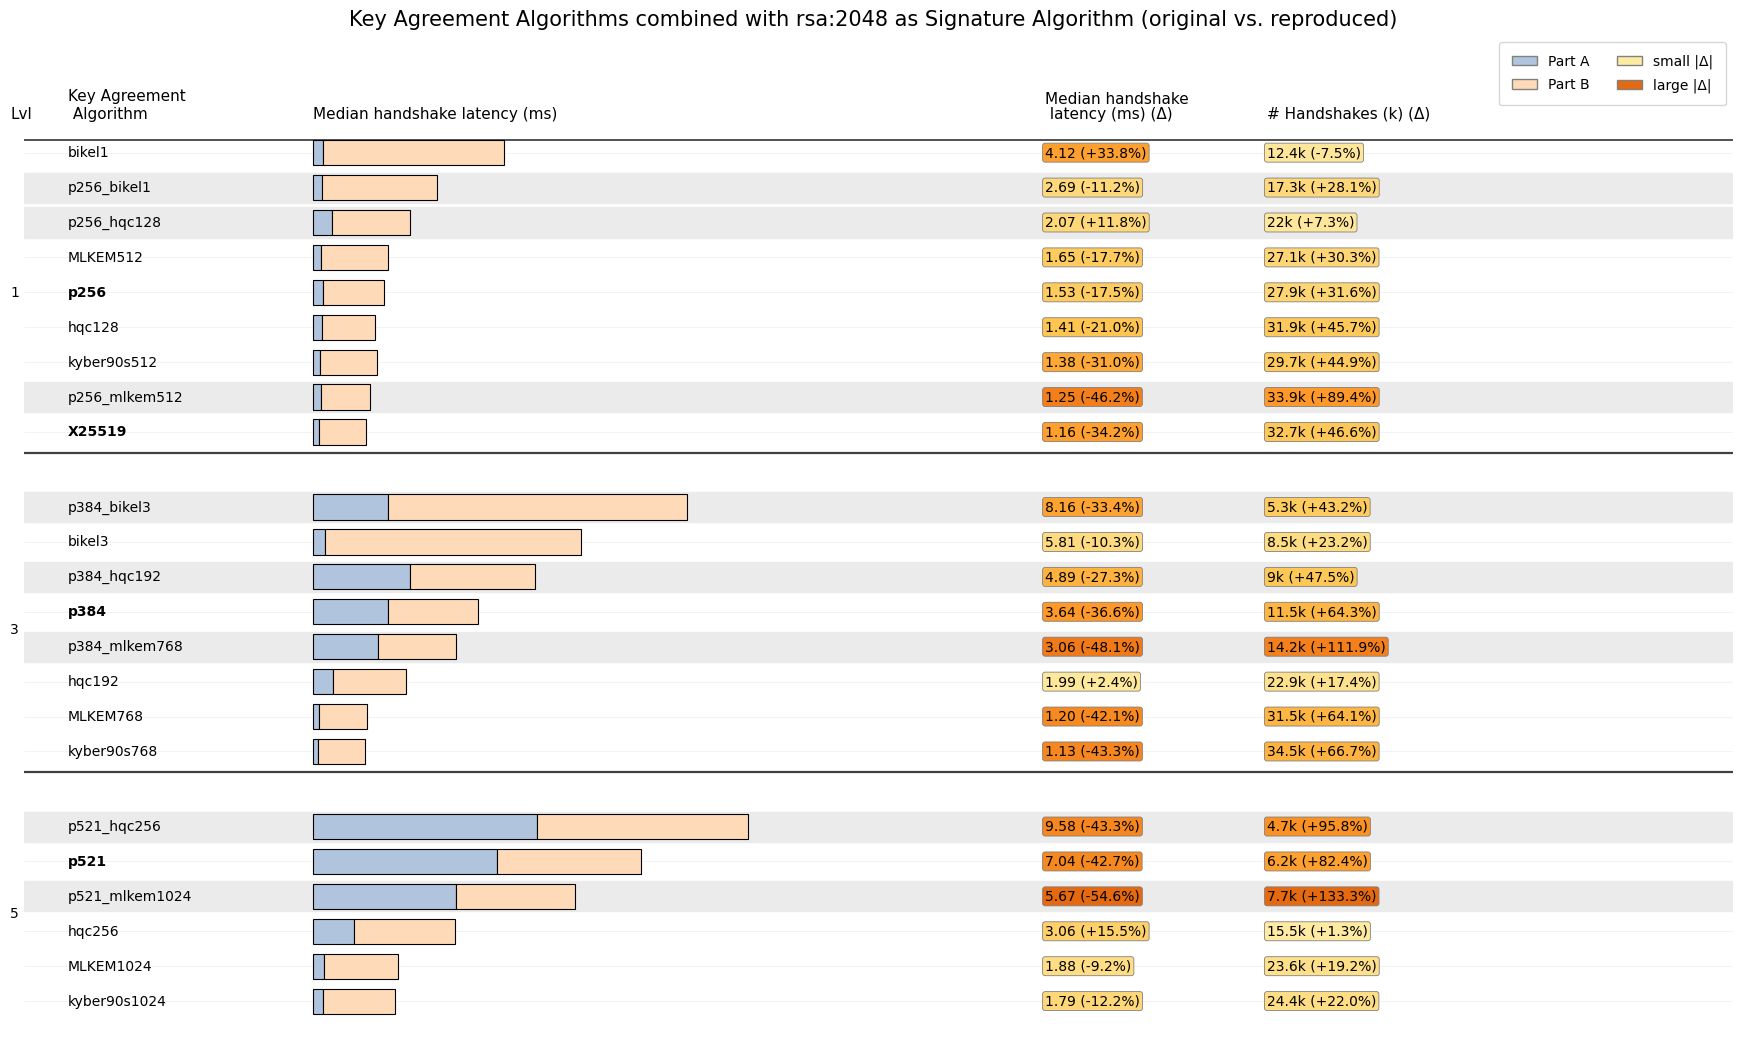

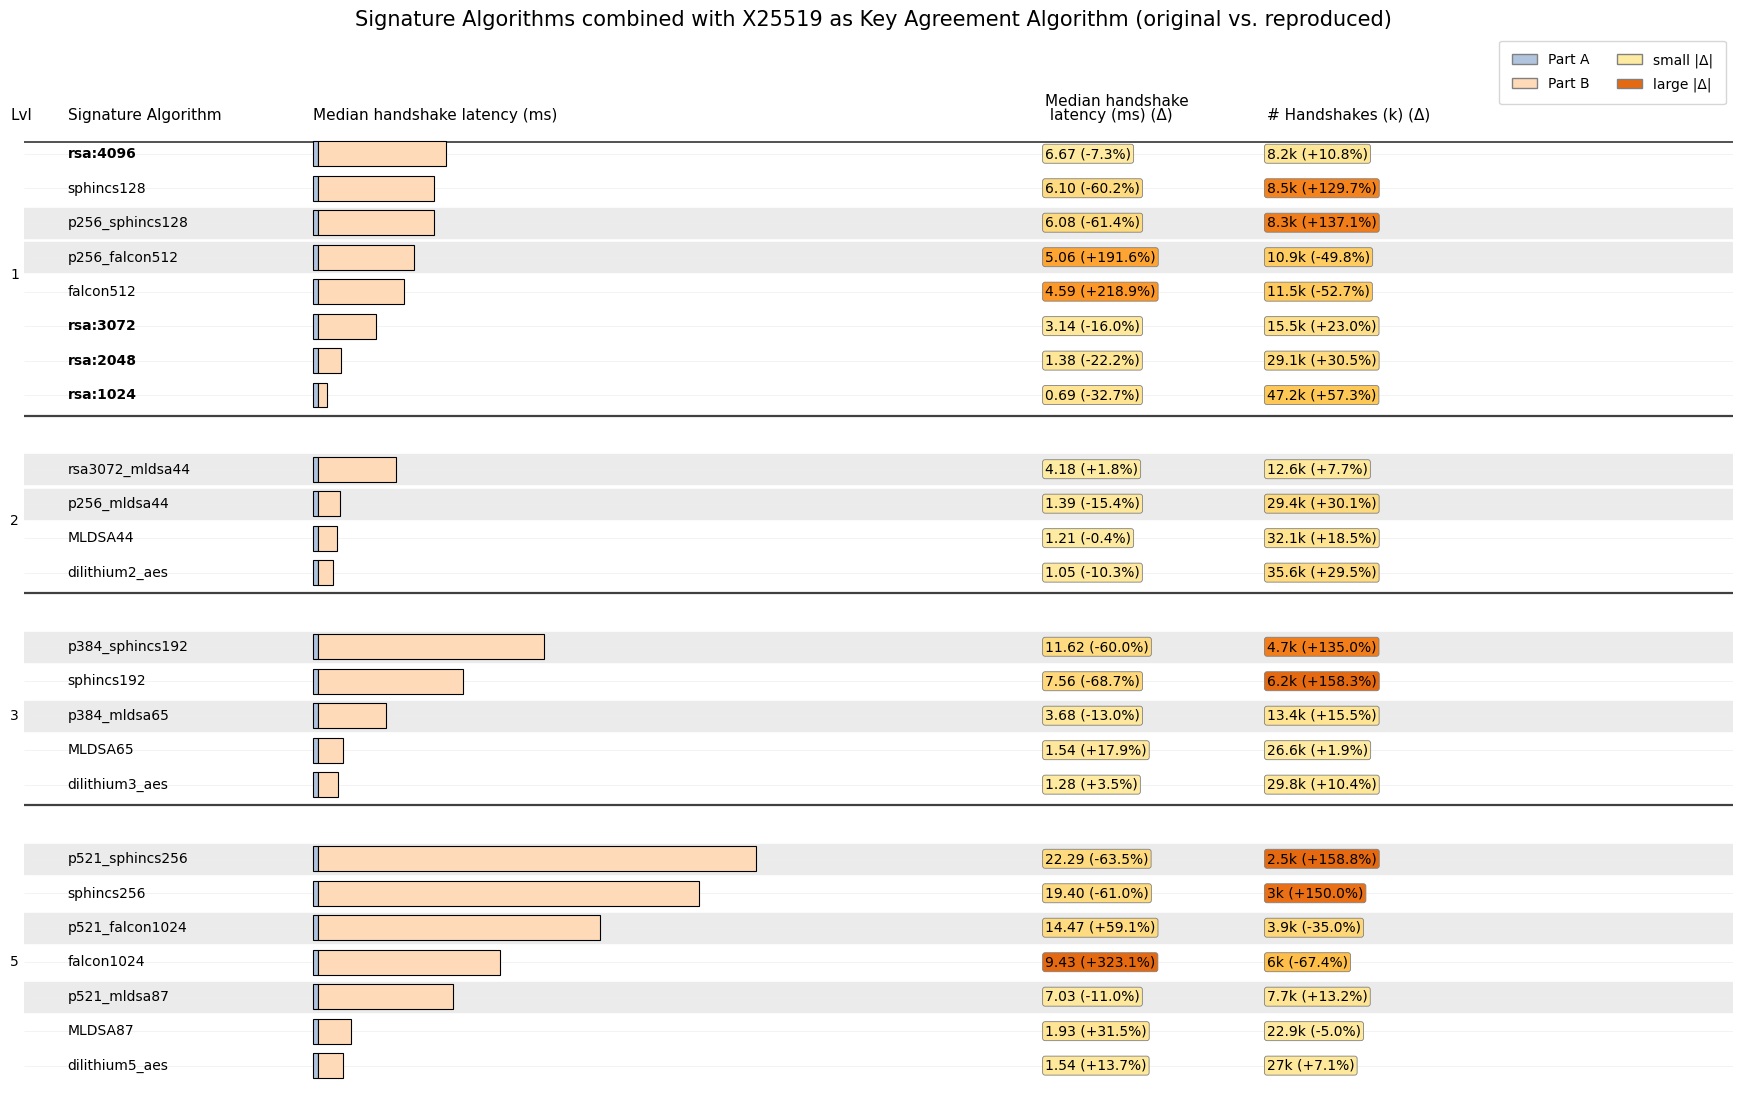

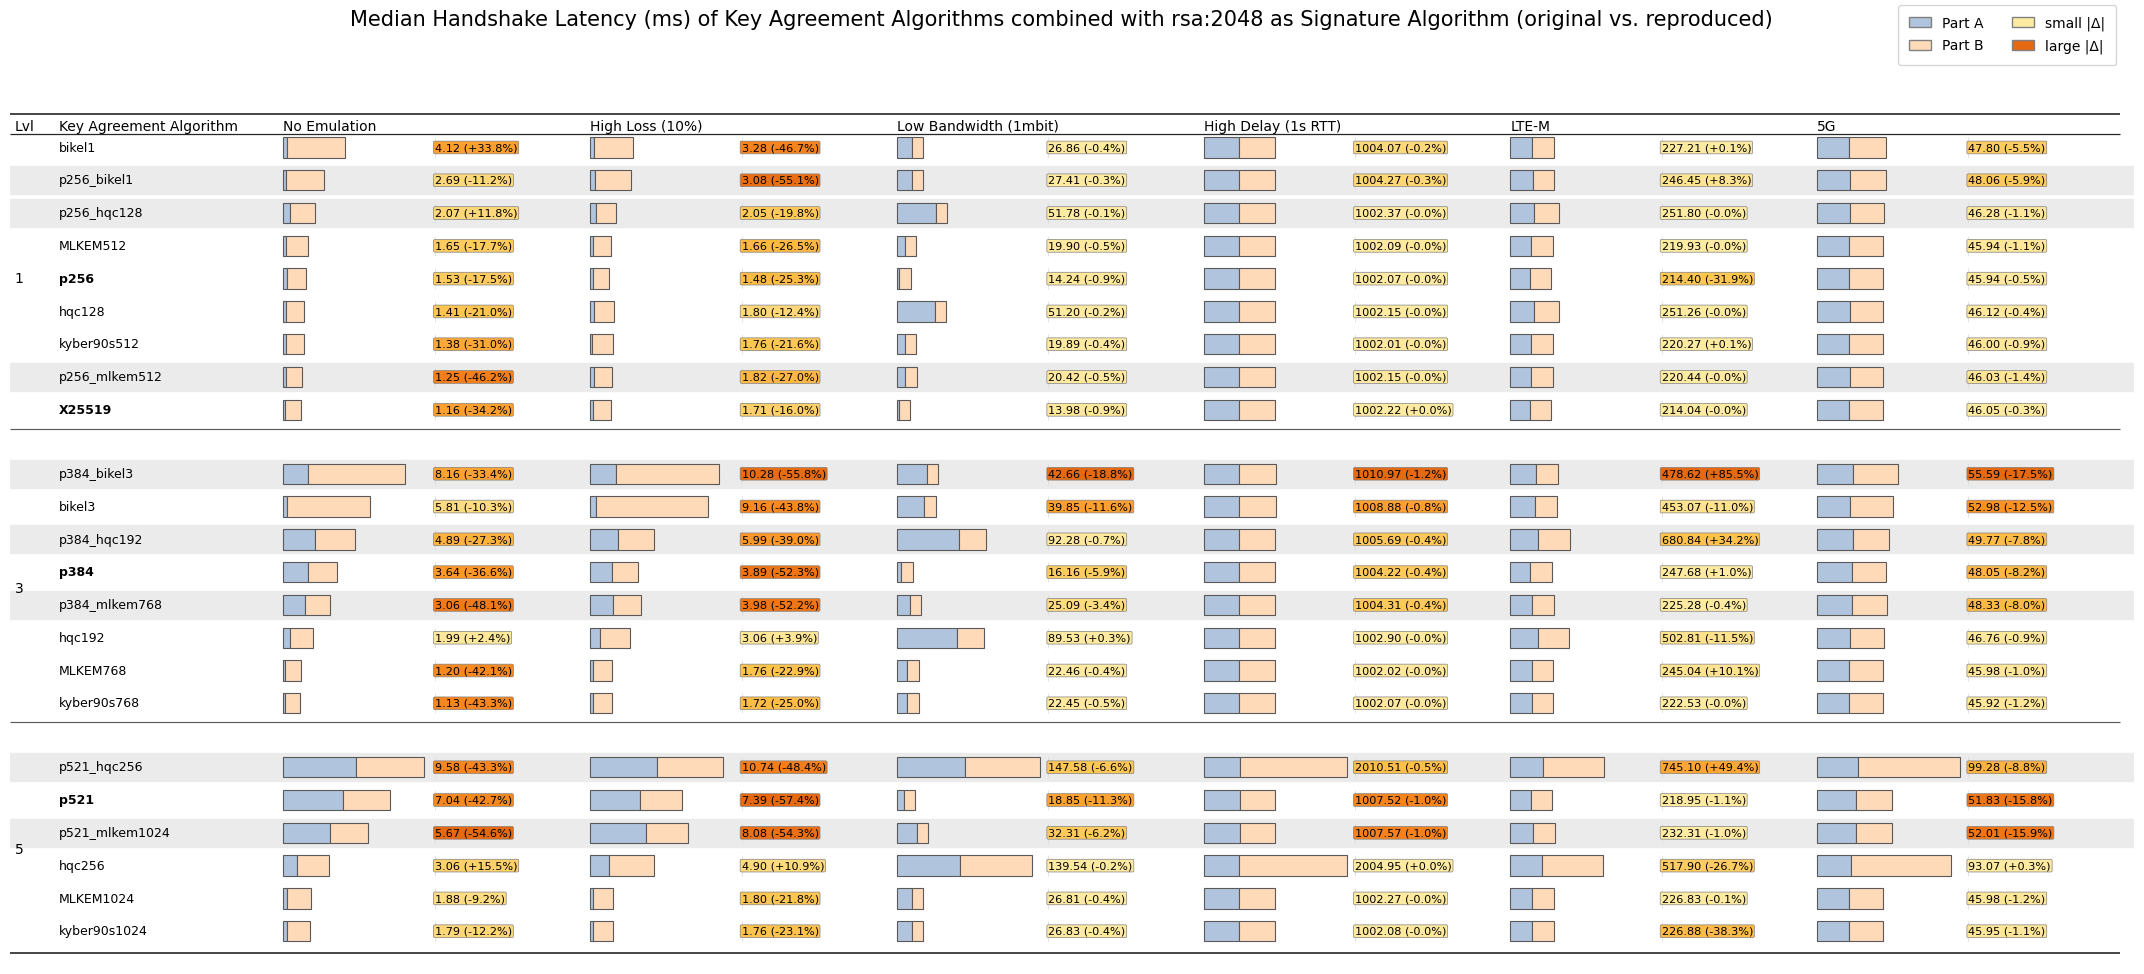

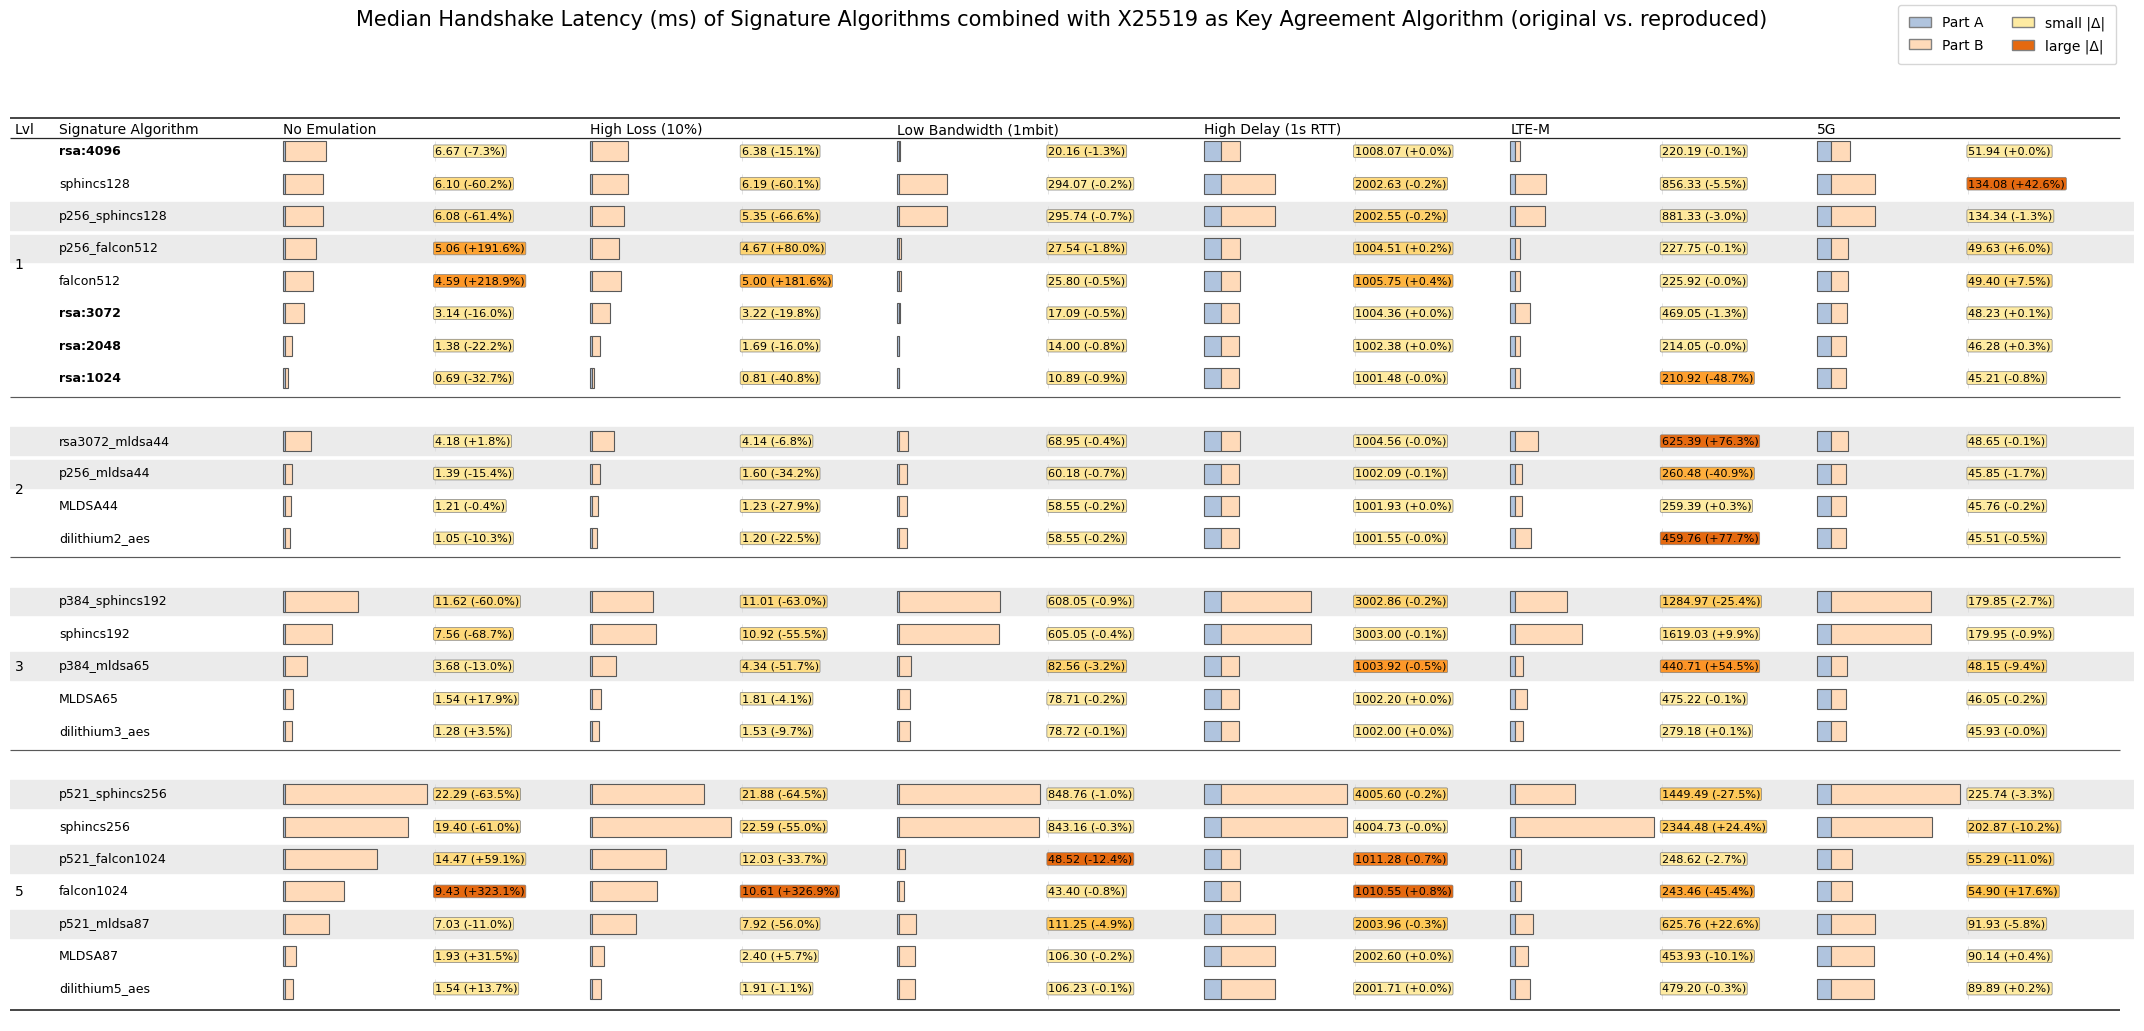

In [13]:
create_table(all_kem, scenario = "kem", emulation="no emulation", title = "Key Agreement Algorithms combined with rsa:2048 as Signature Algorithm (original vs. reproduced)")
create_table(all_sig, scenario = "sig", emulation="no emulation", title = "Signature Algorithms combined with X25519 as Key Agreement Algorithm (original vs. reproduced)")

scenario_order = ["no emulation", "loss 10%", "rate 1mbit", "delay 500ms", "loss 10% delay 100ms rate 1mbit", "loss 4% delay 22ms rate 880mbit"]

create_table_scenarios(mode = "kem", scenario_order = scenario_order, metric = "partAllMedian", title = "Median Handshake Latency (ms) of Key Agreement Algorithms combined with rsa:2048 as Signature Algorithm (original vs. reproduced)")
create_table_scenarios(mode = "sig", scenario_order = scenario_order, metric = "partAllMedian", title = "Median Handshake Latency (ms) of Signature Algorithms combined with X25519 as Key Agreement Algorithm (original vs. reproduced)")

## Results with the adapted code

### Results with the OpenSSL buffer

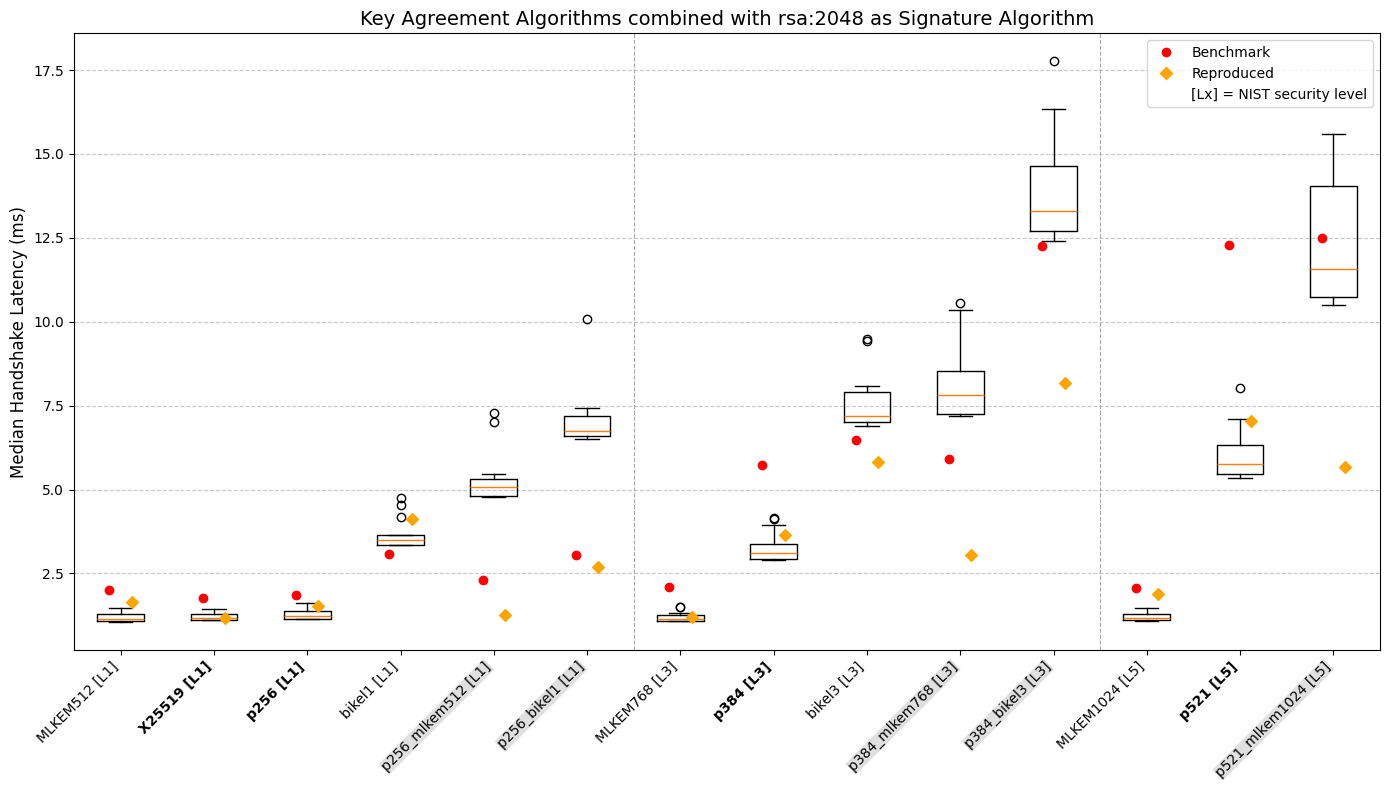

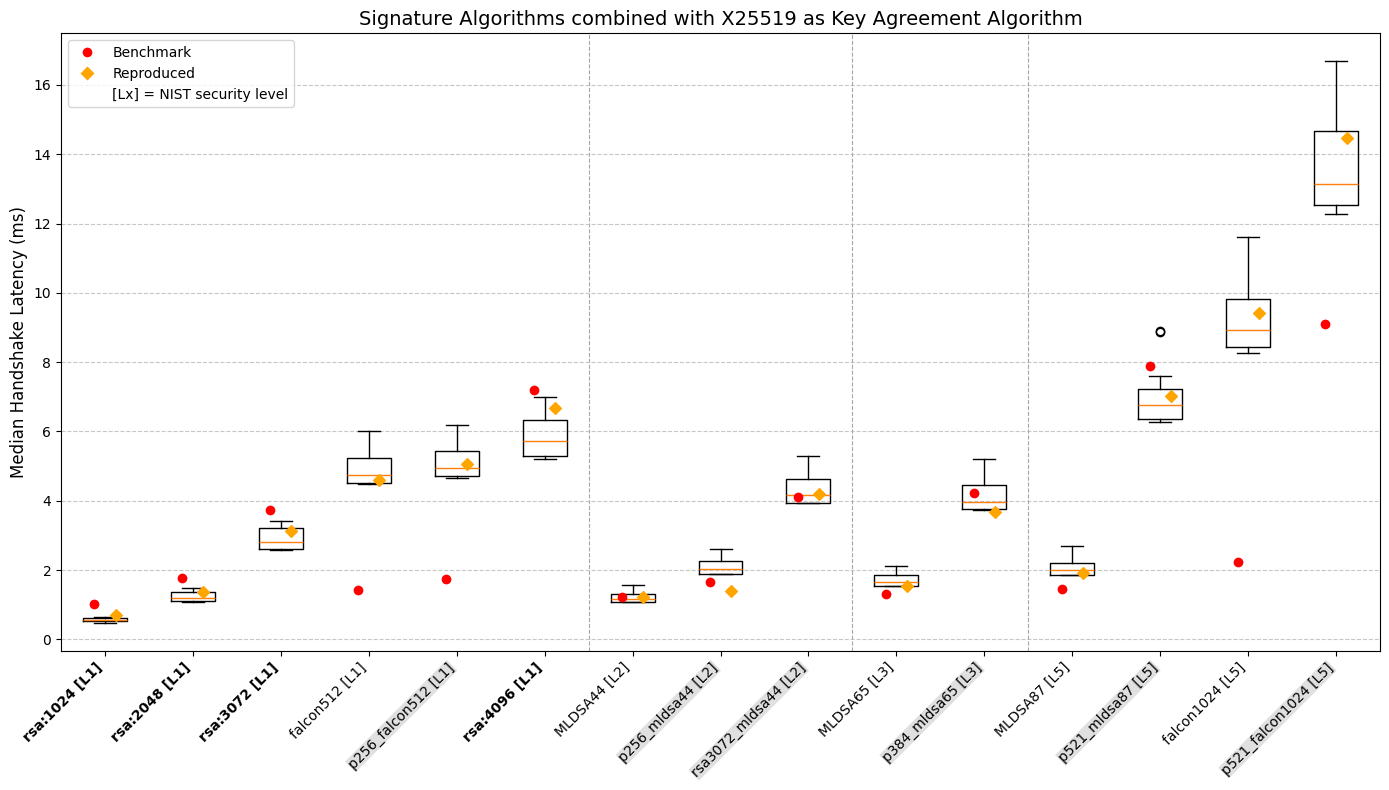

In [14]:
boxplots(all_kem, "no emulation", "part all median", title = "Key Agreement Algorithms combined with rsa:2048 as Signature Algorithm", ylabel = "Median Handshake Latency (ms)")
boxplots(all_sig, "no emulation", "part all median", title = "Signature Algorithms combined with X25519 as Key Agreement Algorithm", ylabel = "Median Handshake Latency (ms)")

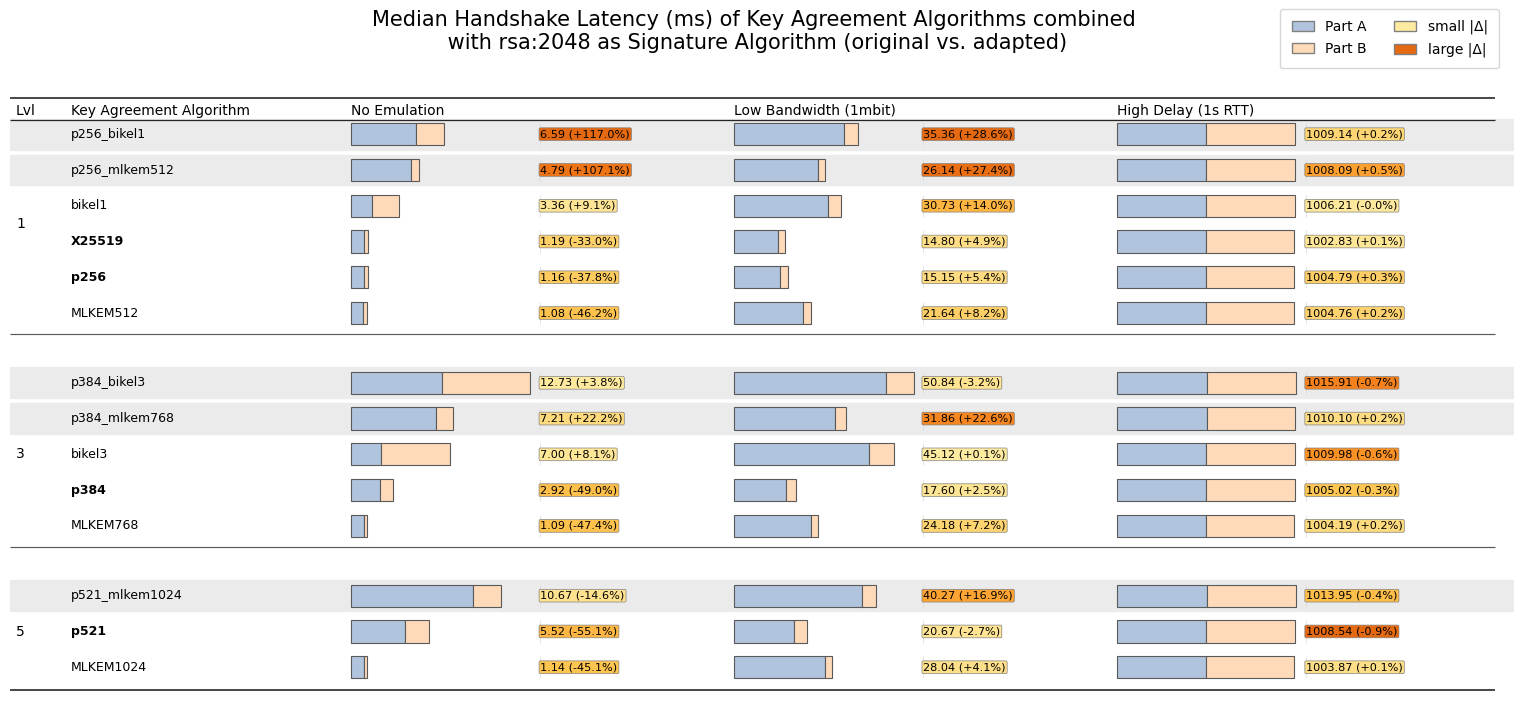

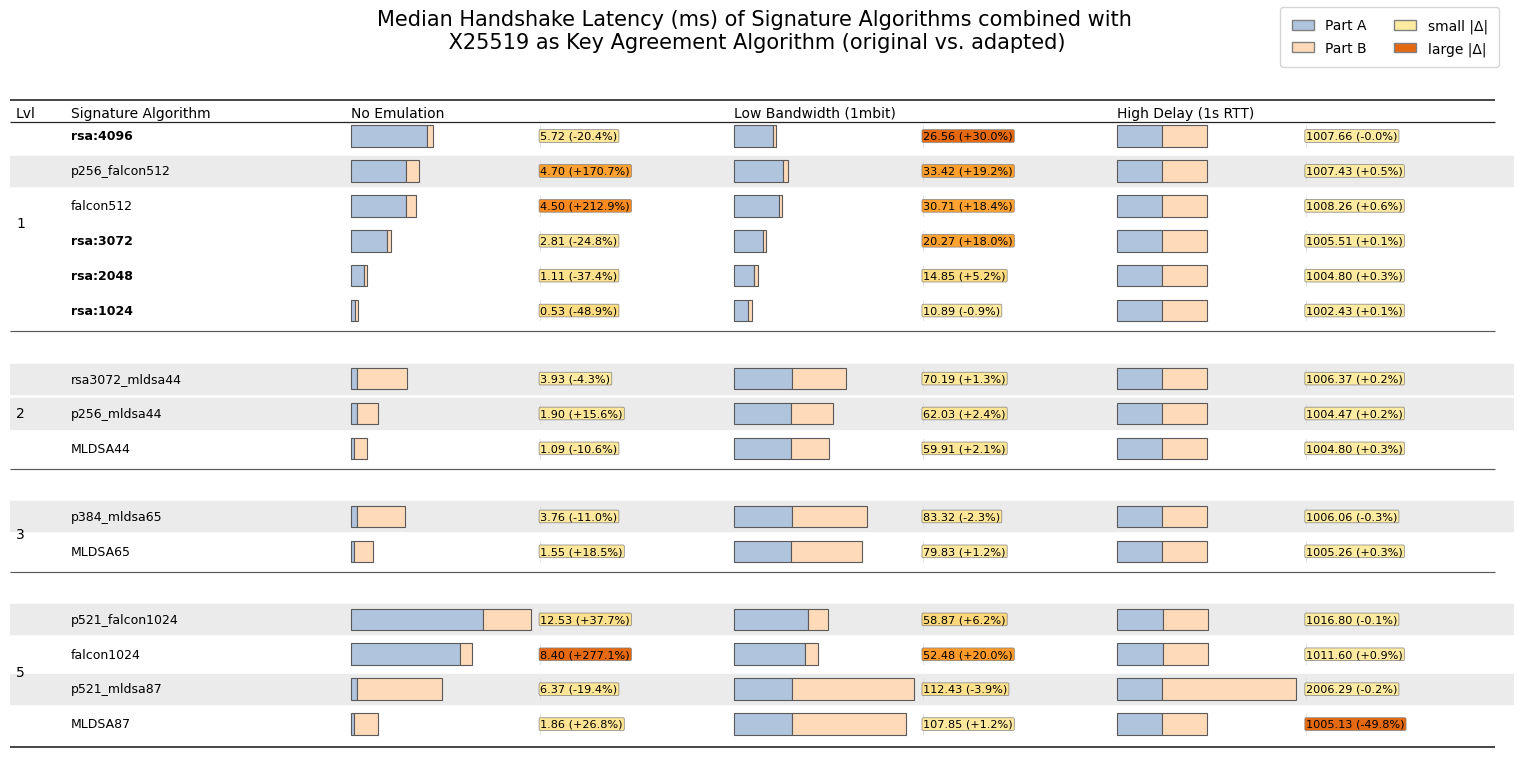

In [15]:
exp_id = 2
kem_used, sig_used = load_single_experiment_for_table4(exp_id)
create_table_scenarios(mode = "kem", metric = "partAllMedian", scenario_order = ["no emulation", "rate 1mbit", "delay 500ms"], algorithms = kem_used, title = "Median Handshake Latency (ms) of Key Agreement Algorithms combined\n with rsa:2048 as Signature Algorithm (original vs. adapted)")
create_table_scenarios(mode = "sig", metric = "partAllMedian", scenario_order = ["no emulation", "rate 1mbit", "delay 500ms"], algorithms = sig_used, title = "Median Handshake Latency (ms) of Signature Algorithms combined with\n X25519 as Key Agreement Algorithm (original vs. adapted)")

### Results without the buffer

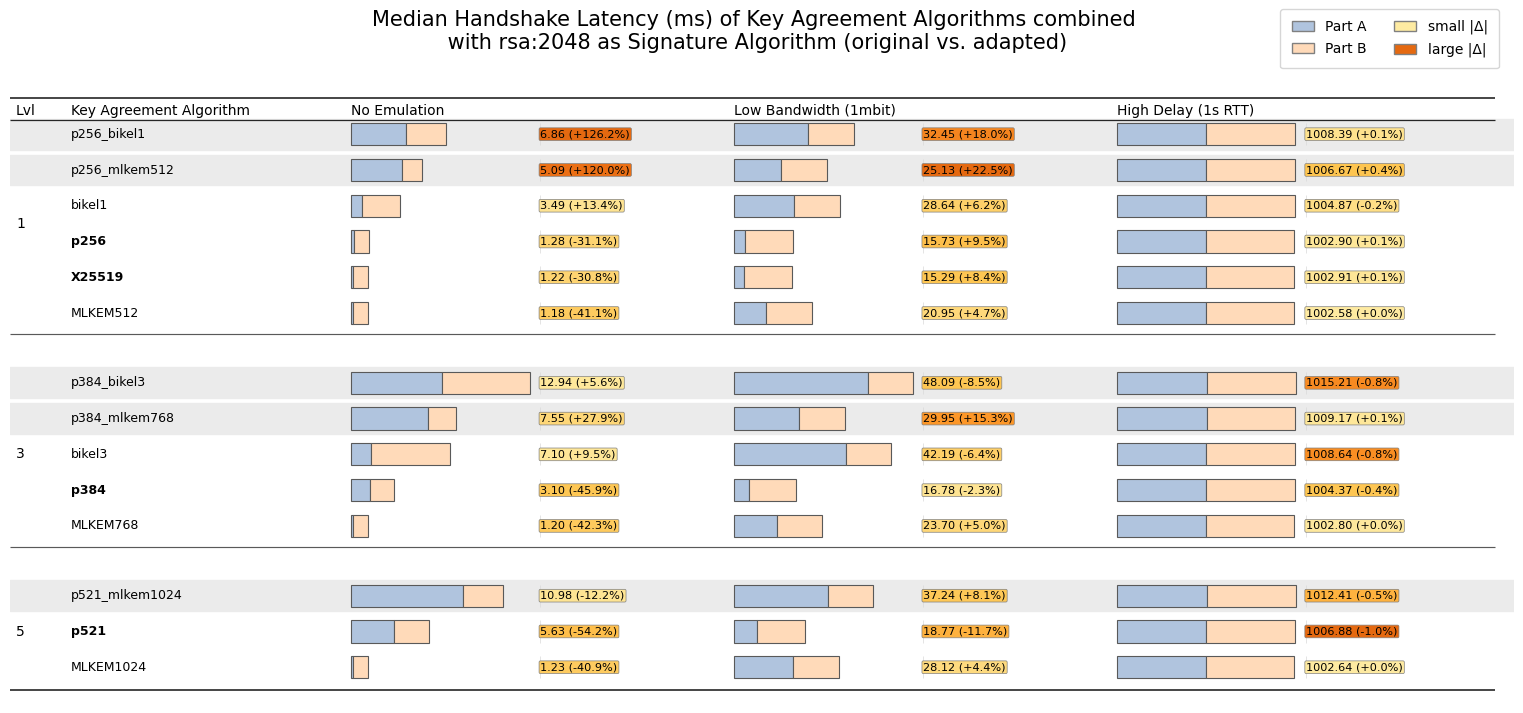

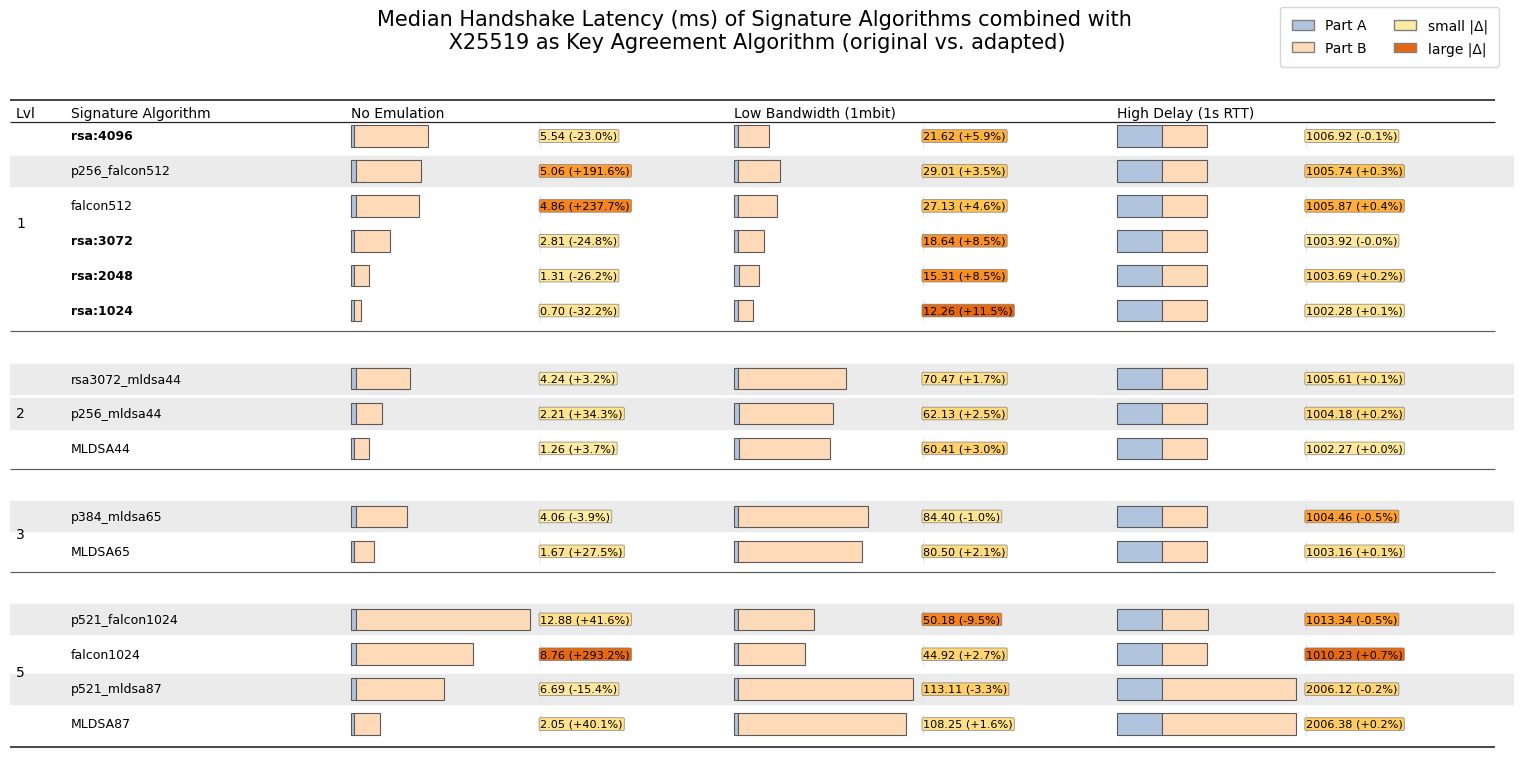

In [16]:
exp_id = "-flush"
kem_used, sig_used = load_single_experiment_for_table4(exp_id)
create_table_scenarios(mode = "kem", metric = "partAllMedian", scenario_order = ["no emulation", "rate 1mbit", "delay 500ms"], algorithms = kem_used, title = "Median Handshake Latency (ms) of Key Agreement Algorithms combined\n with rsa:2048 as Signature Algorithm (original vs. adapted)")
create_table_scenarios(mode = "sig", metric = "partAllMedian", scenario_order = ["no emulation", "rate 1mbit", "delay 500ms"], algorithms = sig_used, title = "Median Handshake Latency (ms) of Signature Algorithms combined with\n X25519 as Key Agreement Algorithm (original vs. adapted)")